# Change-Based Correlation Analysis

Sales response to **% changes** (vs 7-day average) in price, TE margin, and Walmart margin — companion to `correlation_analysis.ipynb` which analyzes absolute levels. See `docs/change-based-analysis-plan.md` for design.

**Predictors:** `cost_to_walmart_vs_7d_pct`, `te_margin_vs_7d_pct`, `walmart_margin_vs_7d_pct`  
**Outcomes:** `qty_sold`, `revenue`  
**Variants:** V1 continuous · V2 threshold (|%| ≥ 1%) · V3 directional buckets

In [1]:
# === PARAMETERS ===
END_DATE = "2026-03-25"
USE_CACHED = False   # True: load outputs/correlation_dataset_{END_DATE}.parquet
                    # False: fresh DataPreparation (~15 min, needs DW/Google/pricing_module)

THRESHOLD_PCT = 0.01             # V2 threshold (matches pipeline min_price_change_pct)
DIRECTIONAL_BINS = [-1.0, -0.05, -0.01, 0.01, 0.05, 1.0]
DIRECTIONAL_LABELS = [
    "big_decrease (<-5%)",
    "small_decrease (-5..-1%)",
    "stable (-1..1%)",
    "small_increase (1..5%)",
    "big_increase (>5%)",
]
CHANGE_COLS = [
    "cost_to_walmart_vs_7d_pct",
    "te_margin_vs_7d_pct",
    "walmart_margin_vs_7d_pct",
]
CONTROLS = ["can_show_inv", "day_of_week", "n_active_nodes", "days_since_price_change"]
OUTCOME_COLS = ["qty_sold", "revenue"]

ITS_TOP_N = 20
ITS_MIN_EVENTS = 2
NB_MIN_OBS = 200

# === IMPORTS ===
import sys, os, warnings, logging
from pathlib import Path
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats as sp_stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.discrete.discrete_model import NegativeBinomial
from statsmodels.stats.outliers_influence import variance_inflation_factor

from src.analysis.config import load_analysis_config
from src.analysis import statistical_tests, did_effects

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

cfg = load_analysis_config()
ci_level = cfg["ci"]["level"]
print(f"Setup complete. CI level={ci_level}, USE_CACHED={USE_CACHED}")

Setup complete. CI level=0.95, USE_CACHED=False


In [2]:
# === LOAD DATA ===
project_root = Path("..").resolve()
cached_parquet = project_root / "outputs" / f"correlation_dataset_{END_DATE}.parquet"

if USE_CACHED and cached_parquet.exists():
    print(f"Loading cached parquet: {cached_parquet.name}")
    df = pd.read_parquet(cached_parquet)
    prep = None
else:
    print("Building master DataFrame fresh via AnalysisDataPrep (~15 min)...")
    from src.analysis.data_prep import AnalysisDataPrep
    ROLLBACKS_PATH = r"G:\Shared drives\07_Finance\07_10_Pricing_department\07_11_01_WalmartB2B\07_10_01_03 Rollbacks\WalmartB2B Rollbacks tracker.xlsx"
    ROLLBACKS_EXCLUDE_START_DATE = "2026-03-18"
    WAREHOUSE_ADDRESSES_PATH = str(project_root / "Warehouse Addresses 03-25-2026 01-43-16 PM.csv")
    prep = AnalysisDataPrep(
        end_date=END_DATE,
        rollbacks_path=ROLLBACKS_PATH,
        rollbacks_exclude_start_date=ROLLBACKS_EXCLUDE_START_DATE,
        warehouse_addresses_path=WAREHOUSE_ADDRESSES_PATH,
    )
    df = prep.run()

# Sanity checks
assert all(c in df.columns for c in CHANGE_COLS), f"Missing change cols in df"
assert all(c in df.columns for c in OUTCOME_COLS), f"Missing outcome cols in df"
print(f"Shape: {df.shape}  Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print("\nChange-column non-null counts:")
for c in CHANGE_COLS:
    n = df[c].notna().sum()
    print(f"  {c}: {n:,} ({n/len(df):.1%})")

2026-04-24 15:05:06,088 INFO Analysis window: 2025-12-26 to 2026-03-25 (warmup from 2025-12-19)
2026-04-24 15:05:06,089 INFO Loading source: dw_walmart_sales (type=sql)


Building master DataFrame fresh via AnalysisDataPrep (~15 min)...


2026-04-24 15:05:06,535 INFO Data warehouse module loaded.
2026-04-24 15:10:44,590 INFO Sales rows (last 60 days): 313,856
2026-04-24 15:10:44,782 INFO Top 90% SKUs selected: 7,759 / 23,983
2026-04-24 15:10:44,783 INFO Loading source: rollbacks (type=local)
2026-04-24 15:10:51,028 INFO Excluding rollbacks with Start date = 2026-03-18
2026-04-24 15:10:51,043 INFO Excluded 1056 rollback SKUs, 6703 remaining
2026-04-24 15:10:51,093 INFO Loading source: dw_walmart_sales (type=sql)
2026-04-24 15:11:42,783 INFO Sales rows after filtering: 218,621
2026-04-24 15:11:43,153 INFO Unique SKU-Nodes (all): 75,056
2026-04-24 15:11:43,213 INFO Removed 0 SKU-Nodes with 0 sales; 75,056 remaining
2026-04-24 15:11:49,621 INFO Scaffold: 7,280,432 rows (75,056 SKU-Nodes x 97 days)
2026-04-24 15:12:01,792 INFO Initializing Google API service connection...
2026-04-24 15:12:02,530 INFO file_cache is only supported with oauth2client<4.0.0
2026-04-24 15:12:02,572 INFO file_cache is only supported with oauth2clie

Download 100.


2026-04-24 15:12:13,964 INFO Loaded DSV 1/46: dsvpriceupload-walmartb2b-2025-11-25_04-28-27.csv (236185 rows)


...

Download 100.
Last modified time 2026-03-24T10:01:40.350Z
Download 96.
Download 100.


2026-04-24 15:41:51,644 INFO   -> 503939 SKU-Node pairs with inventory
2026-04-24 15:41:51,647 INFO Loading inventory for 2026-03-25...


Download 100.
Last modified time 2026-03-25T10:01:25.883Z
Download 96.
Download 100.


2026-04-24 15:42:33,893 INFO   -> 504975 SKU-Node pairs with inventory
2026-04-24 15:43:02,048 INFO Inventory coverage: 78.6%
2026-04-24 15:43:15,089 INFO Computed columns added.
2026-04-24 15:44:26,130 INFO Rolling comparison columns added for: ['qty_sold', 'te_margin', 'cost_to_walmart', 'offer_price', 'walmart_margin']
2026-04-24 15:44:35,934 INFO Trimmed warmup: (6755040, 38) -> 2025-12-26 00:00:00 to 2026-03-25 00:00:00
2026-04-24 15:44:35,940 INFO Final dataset shape: (6755040, 38)


Shape: (6755040, 38)  Date range: 2025-12-26 to 2026-03-25

Change-column non-null counts:
  cost_to_walmart_vs_7d_pct: 5,318,911 (78.7%)
  te_margin_vs_7d_pct: 4,894,013 (72.4%)
  walmart_margin_vs_7d_pct: 5,313,337 (78.7%)


## 1. Build event-definition variants

- **V1** continuous — the raw `_vs_7d_pct` columns, used directly as regressors.
- **V2** threshold binary — `|pct| >= 1%`, used as DiD treatment and ITS marker.
- **V3** directional 5-bin — used as categorical regressor and for ANOVA.

In [3]:
# V2: threshold flags
for col in CHANGE_COLS:
    df[f"{col}_v2"] = (df[col].abs() >= THRESHOLD_PCT).astype(int)
    df.loc[df[col].isna(), f"{col}_v2"] = np.nan

# V3: directional buckets
for col in CHANGE_COLS:
    df[f"{col}_v3"] = pd.cut(
        df[col], bins=DIRECTIONAL_BINS, labels=DIRECTIONAL_LABELS, include_lowest=True,
    )

summary = {}
for col in CHANGE_COLS:
    v1_nonzero = (df[col].fillna(0) != 0).sum()
    v2_treated = df[f"{col}_v2"].sum()
    v3_sizes = df[f"{col}_v3"].value_counts().reindex(DIRECTIONAL_LABELS).fillna(0).astype(int)
    summary[col] = {
        "V1 non-null": df[col].notna().sum(),
        "V1 non-zero": v1_nonzero,
        "V2 treated": int(v2_treated),
        **{f"V3 {lbl}": v3_sizes[lbl] for lbl in DIRECTIONAL_LABELS},
    }
variant_summary = pd.DataFrame(summary).T
variant_summary

,V1 non-null,V1 non-zero,V2 treated,V3 big_decrease (<-5%),V3 small_decrease (-5..-1%),V3 stable (-1..1%),V3 small_increase (1..5%),V3 big_increase (>5%)
cost_to_walmart_vs_7d_pct,5318911,4658370,393724,22795,98014,4925187,208280,64633
te_margin_vs_7d_pct,4894013,4318090,1117256,340738,105755,3776757,146531,486115
walmart_margin_vs_7d_pct,5313337,4675848,535447,263909,72907,4777890,46512,122843


## 2. Sample characterization

Distributions of the three % change predictors and a VIF check before the
multi-predictor regressions.

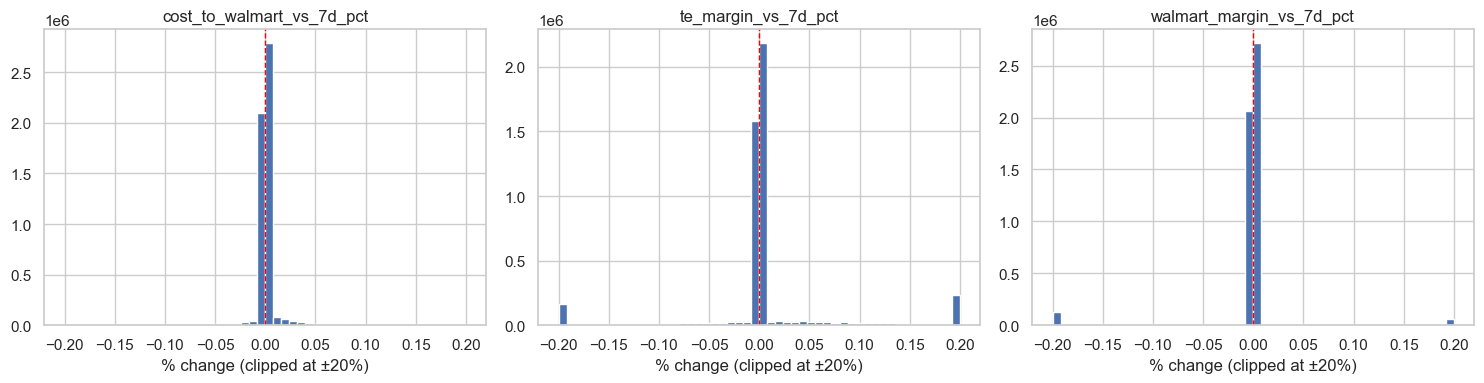

Joint-non-null sample for VIF/regression: 2,355,437 rows
                 variable      VIF
                    const 0.000000
cost_to_walmart_vs_7d_pct 1.000174
      te_margin_vs_7d_pct 1.000173
 walmart_margin_vs_7d_pct 1.000000


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, CHANGE_COLS):
    vals = df[col].dropna()
    clipped = vals.clip(-0.2, 0.2)
    ax.hist(clipped, bins=50, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(col)
    ax.set_xlabel("% change (clipped at ±20%)")
plt.tight_layout()
plt.show()

# VIF on continuous predictors where all three are non-null
sub = df[CHANGE_COLS + CONTROLS].dropna()
X = sm.add_constant(sub[CHANGE_COLS].astype(float).values)
vif_rows = []
for i, col in enumerate(["const"] + CHANGE_COLS):
    try:
        v = variance_inflation_factor(X, i)
    except Exception:
        v = np.nan
    vif_rows.append({"variable": col, "VIF": v})
vif_df = pd.DataFrame(vif_rows)
print(f"Joint-non-null sample for VIF/regression: {len(sub):,} rows")
print(vif_df.to_string(index=False))

## 3. OLS regressions (V1 continuous main effects)

Two specifications: `qty_sold` and `log(1+revenue)`, both on the three % changes +
controls. Reuses `statistical_tests.ols_regression`.

In [5]:
features = CHANGE_COLS + CONTROLS

ols_qty = statistical_tests.ols_regression(
    df, feature_cols=features, target_col="qty_sold", ci_level=ci_level,
)
ols_rev = statistical_tests.ols_regression(
    df, feature_cols=features, target_col="revenue",
    log_transform=True, ci_level=ci_level,
)

for label, res in [("qty_sold (linear)", ols_qty), ("log(1+revenue)", ols_rev)]:
    print(f"\n=== OLS: {label}  n={res['n_obs']:,}  R2={res['r_squared']:.4f} ===")
    c = res["coefficients"]
    display(c[c["variable"].isin(CHANGE_COLS)].round(5))


=== OLS: qty_sold (linear)  n=2,355,437  R2=0.0002 ===


,variable,coef,se,ci_lower,ci_upper,p_value
0,cost_to_walmart_vs_7d_pct,0.06770,0.02609,0.01656,0.11884,0.00946
1,te_margin_vs_7d_pct,0.00016,0.00008,-0.00000,0.00033,0.05505
2,walmart_margin_vs_7d_pct,-0.00000,0.00000,-0.00000,0.00000,0.94097



=== OLS: log(1+revenue)  n=59,217  R2=0.0110 ===


,variable,coef,se,ci_lower,ci_upper,p_value
0,cost_to_walmart_vs_7d_pct,0.19368,0.15364,-0.10746,0.49482,0.20746
1,te_margin_vs_7d_pct,0.00038,0.00029,-0.00018,0.00095,0.18273
2,walmart_margin_vs_7d_pct,0.00012,0.00033,-0.00053,0.00077,0.71848


## 4. Two-way fixed-effects OLS (SKU-Node + date demeaning)

Controls for unobserved SKU-Node and date heterogeneity via within-entity +
within-time demeaning (same approach as `elasticity.estimate_elasticity_fe`).
Clustered SEs at the SKU-Node level.

In [6]:
def two_way_fe_ols(data, y_col, x_cols, entity_col="SKU_Node", time_col="date", ci_level=0.95):
    d = data[[y_col, entity_col, time_col] + x_cols].dropna().copy()
    if len(d) == 0:
        return None
    # Two-way demeaning: iterate until convergence (simple 2-pass for speed)
    y = np.ascontiguousarray(d[y_col].astype(float).values, dtype=float)
    X = np.ascontiguousarray(d[x_cols].astype(float).values, dtype=float).copy()
    entity_idx = d[entity_col].astype("category").cat.codes.values.astype(np.int64)
    time_idx = d[time_col].astype("category").cat.codes.values.astype(np.int64)

    def demean(arr, idx):
        n = int(idx.max()) + 1
        sums = np.bincount(idx, weights=arr, minlength=n)
        counts = np.bincount(idx, minlength=n).astype(float)
        means = np.divide(sums, counts, out=np.zeros_like(sums), where=counts > 0)
        return arr - means[idx]

    # 3-pass alternating demean approximates the two-way within transform
    for _ in range(3):
        y = demean(y, entity_idx)
        y = demean(y, time_idx)
        for j in range(X.shape[1]):
            col = demean(X[:, j].copy(), entity_idx)
            X[:, j] = demean(col, time_idx)

    model = sm.OLS(y, X).fit(cov_type="cluster", cov_kwds={"groups": entity_idx})
    z = sp_stats.norm.ppf(1 - (1 - ci_level) / 2)
    p = np.asarray(model.params); b = np.asarray(model.bse); pv = np.asarray(model.pvalues)
    rows = []
    for i, name in enumerate(x_cols):
        rows.append({
            "variable": name,
            "coef": float(p[i]),
            "se": float(b[i]),
            "ci_lower": float(p[i] - z * b[i]),
            "ci_upper": float(p[i] + z * b[i]),
            "p_value": float(pv[i]),
        })
    return {"coef_df": pd.DataFrame(rows), "n_obs": int(model.nobs), "r_squared": float(model.rsquared)}

if "SKU_Node" not in df.columns:
    df["SKU_Node"] = df["sku"].astype(str) + "-" + df["node"].astype(str)

fe_res = two_way_fe_ols(df, "qty_sold", CHANGE_COLS, ci_level=ci_level)
print(f"Two-way FE OLS: n={fe_res['n_obs']:,}  within-R2={fe_res['r_squared']:.4f}")
display(fe_res["coef_df"].round(5))

Two-way FE OLS: n=4,889,060  within-R2=0.0000


,variable,coef,se,ci_lower,ci_upper,p_value
0,cost_to_walmart_vs_7d_pct,0.03356,0.04954,-0.06353,0.13065,0.49810
1,te_margin_vs_7d_pct,0.00001,0.00000,0.00000,0.00002,0.01799
2,walmart_margin_vs_7d_pct,0.00000,0.00000,-0.00000,0.00000,0.90736


## 5. Negative Binomial on `qty_sold | qty_sold > 0`

Count model restricted to sale days, avoids the 97% zero-inflation issue.

In [7]:
sale_days = df[df["qty_sold"] > 0].dropna(subset=CHANGE_COLS + ["qty_sold"])
print(f"Sale-day sample: {len(sale_days):,}")

nb_res = None
if len(sale_days) >= NB_MIN_OBS:
    X = sm.add_constant(sale_days[CHANGE_COLS].astype(float))
    y = sale_days["qty_sold"].astype(float)
    try:
        nb_model = NegativeBinomial(y, X).fit(disp=False, maxiter=200)
        z = sp_stats.norm.ppf(1 - (1 - ci_level) / 2)
        p = np.asarray(nb_model.params); b = np.asarray(nb_model.bse); pv = np.asarray(nb_model.pvalues)
        nb_rows = []
        for i, name in enumerate(["const"] + CHANGE_COLS):
            nb_rows.append({
                "variable": name,
                "coef": float(p[i]),
                "se": float(b[i]),
                "ci_lower": float(p[i] - z * b[i]),
                "ci_upper": float(p[i] + z * b[i]),
                "p_value": float(pv[i]),
            })
        nb_res = {
            "coef_df": pd.DataFrame(nb_rows),
            "n_obs": int(nb_model.nobs),
            "pseudo_r2": float(nb_model.prsquared),
        }
        print(f"NegBin: n={nb_res['n_obs']:,}  pseudo-R2={nb_res['pseudo_r2']:.4f}")
        display(nb_res["coef_df"][nb_res["coef_df"]["variable"].isin(CHANGE_COLS)].round(5))
    except Exception as e:
        print(f"NegBin failed: {e}")
else:
    print(f"Skipping NegBin: fewer than {NB_MIN_OBS} sale-day rows")

Sale-day sample: 134,782
NegBin: n=134,782  pseudo-R2=0.0000


,variable,coef,se,ci_lower,ci_upper,p_value
1,cost_to_walmart_vs_7d_pct,0.08772,0.13252,-0.17201,0.34745,0.50801
2,te_margin_vs_7d_pct,0.00008,0.00024,-0.00039,0.00055,0.74757
3,walmart_margin_vs_7d_pct,0.00006,0.00028,-0.00049,0.00060,0.84091


## 6. Semi-log own-price elasticity

Pooled and within-entity (FE) specifications of `log(1+qty_sold) ~ β·pct_price`.
Semi-log is used because signed % changes break log-log. The coefficient β is
interpreted as the % change in (1+qty) per 1pp change in price.

In [8]:
def semilog_elasticity(data, pct_col, y_col="qty_sold", cluster_col=None, ci_level=0.95):
    d = data[[pct_col, y_col] + ([cluster_col] if cluster_col else [])].dropna()
    if len(d) < 100:
        return None
    y = np.log1p(d[y_col].astype(float).clip(lower=0))
    X = sm.add_constant(d[pct_col].astype(float))
    if cluster_col is not None:
        groups = d[cluster_col].astype("category").cat.codes.values
        model = sm.OLS(y, X).fit(cov_type="cluster", cov_kwds={"groups": groups})
    else:
        model = sm.OLS(y, X).fit(cov_type="HC1")
    z = sp_stats.norm.ppf(1 - (1 - ci_level) / 2)
    beta = float(model.params.iloc[1])
    se = float(model.bse.iloc[1])
    return {
        "beta": beta, "se": se,
        "ci_lower": beta - z * se, "ci_upper": beta + z * se,
        "p_value": float(model.pvalues.iloc[1]), "n_obs": int(model.nobs),
    }

def semilog_elasticity_fe(data, pct_col, y_col="qty_sold", entity_col="SKU_Node", ci_level=0.95):
    d = data[[pct_col, y_col, entity_col]].dropna()
    if len(d) < 100:
        return None
    y = np.ascontiguousarray(np.log1p(d[y_col].astype(float).clip(lower=0)).values, dtype=float)
    x = np.ascontiguousarray(d[pct_col].astype(float).values, dtype=float)
    idx = d[entity_col].astype("category").cat.codes.values.astype(np.int64)
    def demean(arr, idx):
        n = int(idx.max()) + 1
        sums = np.bincount(idx, weights=arr, minlength=n)
        counts = np.bincount(idx, minlength=n).astype(float)
        means = np.divide(sums, counts, out=np.zeros_like(sums), where=counts > 0)
        return arr - means[idx]
    y_dm = demean(y, idx)
    x_dm = demean(x, idx)
    # Keep entities with within-variation
    mask = np.abs(x_dm) > 1e-12
    if mask.sum() < 100:
        return None
    model = sm.OLS(y_dm[mask], x_dm[mask]).fit(cov_type="cluster", cov_kwds={"groups": idx[mask]})
    z = sp_stats.norm.ppf(1 - (1 - ci_level) / 2)
    params = np.asarray(model.params)
    bse = np.asarray(model.bse)
    pvals = np.asarray(model.pvalues)
    beta = float(params[0])
    se = float(bse[0])
    return {
        "beta": beta, "se": se,
        "ci_lower": beta - z * se, "ci_upper": beta + z * se,
        "p_value": float(pvals[0]), "n_obs": int(model.nobs),
    }

elast_pooled = semilog_elasticity(df, "cost_to_walmart_vs_7d_pct", cluster_col="SKU_Node", ci_level=ci_level)
elast_fe = semilog_elasticity_fe(df, "cost_to_walmart_vs_7d_pct", ci_level=ci_level)
elast_df = pd.DataFrame({
    "spec": ["Pooled (SKU-Node clustered)", "Within-entity FE"],
    **{k: [elast_pooled[k] if elast_pooled else np.nan, elast_fe[k] if elast_fe else np.nan] for k in ["beta", "se", "ci_lower", "ci_upper", "p_value", "n_obs"]},
})
print("=== Semi-log own-price elasticity (β = Δlog(1+qty) per 1pp change in cost) ===")
display(elast_df.round(5))

=== Semi-log own-price elasticity (β = Δlog(1+qty) per 1pp change in cost) ===


,spec,beta,se,ci_lower,ci_upper,p_value,n_obs
0,Pooled (SKU-Node clustered),0.01647,0.00916,-0.00148,0.03442,0.07214,5318911
1,Within-entity FE,0.03527,0.00889,0.01785,0.05269,0.00007,3491869


## 7. Diff-in-Diff on threshold (V2) price-change events

Uses `did_effects.build_did_panel` + `heterogeneous_did`. Treatment column is
`cost_to_walmart_vs_7d_pct` **masked to zero** where `|pct| < 1%` so only material
changes define treated SKU-Nodes.

In [9]:
# build_did_panel is O(n_treated * n_rows) — pre-subsample the universe
# to a tractable set of top-event SKU-Nodes + random controls.
DID_TOP_TREATED = 300      # top SKU-Nodes by V2 event count
DID_N_CONTROLS = 600       # random never-V2 SKU-Nodes as control pool

df_did_src = df.copy()
if "SKU_Node" not in df_did_src.columns:
    df_did_src["SKU_Node"] = df_did_src["sku"].astype(str) + "-" + df_did_src["node"].astype(str)

event_counts = (
    df_did_src.assign(_v2=(df_did_src["cost_to_walmart_vs_7d_pct"].abs() >= THRESHOLD_PCT).astype(int))
    .groupby("SKU_Node")["_v2"].sum()
)
treated_universe = event_counts.sort_values(ascending=False).head(DID_TOP_TREATED).index
control_pool = event_counts[event_counts == 0].index
rng = np.random.default_rng(42)
control_universe = rng.choice(control_pool, size=min(DID_N_CONTROLS, len(control_pool)), replace=False)
keep = set(treated_universe) | set(control_universe)
print(f"DiD universe: {len(treated_universe)} treated + {len(control_universe)} controls = {len(keep)} SKU-Nodes")

df_did = df_did_src[df_did_src["SKU_Node"].isin(keep)].copy()
mask_small = df_did["cost_to_walmart_vs_7d_pct"].abs() < THRESHOLD_PCT
df_did["treatment_pct_v2"] = df_did["cost_to_walmart_vs_7d_pct"].where(~mask_small, 0.0).fillna(0.0)
print(f"DiD source df: {len(df_did):,} rows")

panel = did_effects.build_did_panel(
    df_did, treatment_col="treatment_pct_v2",
    max_controls_per_brand=5, pre_window_days=7, post_window_days=14, min_event_buffer_days=14,
)
print(f"DiD panel: {len(panel):,} rows")

did_overall = None
if len(panel) == 0:
    print("DiD panel empty - no eligible events within buffered window.")
    did_brand = pd.DataFrame()
    did_ptier = pd.DataFrame()
else:
    # Pooled overall ATT: qty_sold ~ treated + post + treated_x_post + dow dummies
    dow_d = pd.get_dummies(panel["day_of_week"], prefix="dow", drop_first=True, dtype=float)
    X_pool = pd.concat([panel[["treated", "post", "treated_x_post"]].astype(float), dow_d], axis=1)
    X_pool = sm.add_constant(X_pool, has_constant="add")
    y_pool = panel["qty_sold"].astype(float)
    pool_model = sm.OLS(y_pool.values, X_pool.values).fit(cov_type="HC1")
    z = sp_stats.norm.ppf(1 - (1 - ci_level) / 2)
    pp = np.asarray(pool_model.params); pb = np.asarray(pool_model.bse); ppv = np.asarray(pool_model.pvalues)
    att = float(pp[3]); se = float(pb[3])
    did_overall = {"ATT": att, "se": se, "ci_lower": att - z*se, "ci_upper": att + z*se,
                   "p_value": float(ppv[3]), "n_obs": int(pool_model.nobs)}
    print(f"\n=== Pooled overall ATT (V2 threshold treatment on % price change) ===")
    print(f"ATT={att:+.4f} [{did_overall['ci_lower']:+.4f}, {did_overall['ci_upper']:+.4f}] p={did_overall['p_value']:.4f}  n={did_overall['n_obs']:,}")

    did_brand = did_effects.heterogeneous_did(panel, "brand", top_n=10, min_obs=30, ci_level=ci_level)
    did_ptier = did_effects.heterogeneous_did(panel, "price_tier", top_n=4, min_obs=30, ci_level=ci_level)
    print("\n=== Brand ATT subgroups ===")
    display(did_brand.round(5) if len(did_brand) else "(no subgroup met min_obs)")
    print("\n=== Price-tier ATT subgroups ===")
    display(did_ptier.round(5) if len(did_ptier) else "(no subgroup met min_obs)")

DiD universe: 300 treated + 600 controls = 900 SKU-Nodes
DiD source df: 81,000 rows
DiD panel: 4,114 rows

=== Pooled overall ATT (V2 threshold treatment on % price change) ===
ATT=+0.0120 [-0.0418, +0.0658] p=0.6627  n=4,114

=== Brand ATT subgroups ===


,segment_value,ATT,se,ci_lower,ci_upper,p_value,n_obs
0,BRID,-0.10667,0.06455,-0.23318,0.01984,0.09842,396
1,GOYR,-0.10769,0.08286,-0.27008,0.05471,0.19370,396
2,HANK,-0.00448,0.03526,-0.07358,0.06463,0.89897,374
3,VANT,-0.06104,0.15477,-0.36438,0.24231,0.69331,330
4,FALK,-0.01414,0.06825,-0.14791,0.11964,0.83591,242
5,NEXE,0.10931,0.12824,-0.14203,0.36066,0.39399,242
6,KUMH,-0.02883,0.05928,-0.14502,0.08737,0.62677,220
7,CONT,-0.11673,0.16386,-0.43789,0.20443,0.47624,198
8,COOP,0.04778,0.07818,-0.10545,0.20101,0.54108,198
9,IRON,0.14730,0.18427,-0.21387,0.50847,0.42408,176



=== Price-tier ATT subgroups ===


,segment_value,ATT,se,ci_lower,ci_upper,p_value,n_obs
0,Budget,0.01625,0.03225,-0.04697,0.07946,0.61442,2838
1,Mid,-0.09403,0.05463,-0.20109,0.01303,0.08518,484
2,Premium,-0.06675,0.10697,-0.27641,0.14291,0.53265,418
3,Luxury,0.04774,0.14912,-0.24453,0.34000,0.74888,374


## 8. Interrupted time series on top-20 SKU-Nodes by V2 event count

Per SKU-Node, fit a segmented regression around the first V2 price-change event
with HAC (Newey-West, lag=7) standard errors. Coefficient of interest = level
shift post-event.

In [10]:
def fit_its(sub, event_date):
    sub = sub.sort_values("date").copy()
    sub["t"] = (sub["date"] - sub["date"].min()).dt.days.astype(float)
    sub["post"] = (sub["date"] >= event_date).astype(float)
    sub["t_post"] = sub["post"] * ((sub["date"] - event_date).dt.days.astype(float))
    X = sm.add_constant(sub[["t", "post", "t_post"]])
    y = sub["qty_sold"].astype(float)
    try:
        return sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 7})
    except Exception:
        return None

# Identify first V2 event per SKU-Node
ev = df[df["cost_to_walmart_vs_7d_pct_v2"] == 1].groupby("SKU_Node")["date"].min().rename("first_event")
ev_count = df[df["cost_to_walmart_vs_7d_pct_v2"] == 1].groupby("SKU_Node").size().rename("n_events")
ev = pd.concat([ev, ev_count], axis=1).dropna()
ev = ev[ev["n_events"] >= ITS_MIN_EVENTS].sort_values("n_events", ascending=False).head(ITS_TOP_N)

its_rows = []
z = sp_stats.norm.ppf(1 - (1 - ci_level) / 2)
for sku_node, row in ev.iterrows():
    sub = df[df["SKU_Node"] == sku_node][["date", "qty_sold"]].dropna()
    if len(sub) < 20:
        continue
    res = fit_its(sub, row["first_event"])
    if res is None or "post" not in res.params.index:
        continue
    coef = res.params["post"]
    se = res.bse["post"]
    its_rows.append({
        "SKU_Node": sku_node, "n_events": int(row["n_events"]),
        "level_shift": coef, "se": se,
        "ci_lower": coef - z * se, "ci_upper": coef + z * se,
        "p_value": res.pvalues["post"], "n_obs": int(res.nobs),
    })

its_df = pd.DataFrame(its_rows).sort_values("p_value") if its_rows else pd.DataFrame()
print(f"ITS fitted for {len(its_df)} / {len(ev)} top SKU-Nodes")
if len(its_df):
    display(its_df.head(20).round(4))

ITS fitted for 20 / 20 top SKU-Nodes


,SKU_Node,n_events,level_shift,se,ci_lower,ci_upper,p_value,n_obs
12,KUMH0881825560H-628326168,33,-0.2952,0.1333,-0.5565,-0.0340,0.0268,90
6,HANK2081523575T-6283261476,34,0.3620,0.2216,-0.0723,0.7963,0.1023,90
10,KUMH0881825560H-62832689,33,0.0518,0.0385,-0.0236,0.1271,0.1783,90
9,GOYR0211720555VXL-628326727,33,0.0936,0.0722,-0.0479,0.2351,0.1950,90
11,IRON0111519550V-628326112,33,0.2500,0.1974,-0.1369,0.6369,0.2053,90
1,GOYR0291722560V-6283261278,36,0.2734,0.2313,-0.1799,0.7268,0.2372,90
4,IRON0111923550VXL-628326142,34,-0.0630,0.0543,-0.1695,0.0435,0.2465,90
16,HANK2081723565H-62832670,32,0.0704,0.0620,-0.0512,0.1919,0.2566,90
15,IRON0111723550W-62832665,32,-0.0231,0.0205,-0.0632,0.0169,0.2578,90
14,IRON0111723550W-62832680,32,-0.1537,0.1379,-0.4241,0.1167,0.2652,90


## 9. Directional bucket (V3) comparison

One-way ANOVA + Tukey HSD on `qty_sold` and `revenue` across the 5 directional
buckets, for each of the three change variables.

In [11]:
bucket_rows = []
for change_col in CHANGE_COLS:
    bcol = f"{change_col}_v3"
    for outcome in OUTCOME_COLS:
        sub = df[[bcol, outcome]].dropna()
        groups = [sub.loc[sub[bcol] == lbl, outcome].values for lbl in DIRECTIONAL_LABELS if (sub[bcol] == lbl).sum() > 0]
        if len(groups) < 2:
            continue
        f_stat, p_val = sp_stats.f_oneway(*groups)
        means = sub.groupby(bcol, observed=False)[outcome].agg(["mean", "count"]).reindex(DIRECTIONAL_LABELS)
        row = {"change_col": change_col, "outcome": outcome, "F": f_stat, "p_value": p_val}
        for lbl in DIRECTIONAL_LABELS:
            row[f"mean_{lbl.split(' ')[0]}"] = means.loc[lbl, "mean"] if lbl in means.index else np.nan
            row[f"n_{lbl.split(' ')[0]}"] = int(means.loc[lbl, "count"]) if lbl in means.index else 0
        bucket_rows.append(row)

bucket_df = pd.DataFrame(bucket_rows)
display(bucket_df.round(5))

# One Tukey example for the headline variable
print("\n=== Tukey HSD: qty_sold ~ cost_to_walmart_vs_7d_pct_v3 ===")
sub = df[["cost_to_walmart_vs_7d_pct_v3", "qty_sold"]].dropna().sample(n=min(200_000, len(df)), random_state=42)
tukey = pairwise_tukeyhsd(endog=sub["qty_sold"], groups=sub["cost_to_walmart_vs_7d_pct_v3"].astype(str), alpha=0.05)
print(tukey.summary())

,change_col,outcome,F,p_value,mean_big_decrease,n_big_decrease,mean_small_decrease,n_small_decrease,mean_stable,n_stable,mean_small_increase,n_small_increase,mean_big_increase,n_big_increase
0,cost_to_walmart_vs_7d_pct,qty_sold,3.87921,0.00374,0.07453,22795,0.08724,98014,0.09160,4925187,0.08926,208280,0.09068,64633
1,cost_to_walmart_vs_7d_pct,revenue,7.19370,0.00001,7.28471,22795,8.65831,98014,9.54048,4925187,9.35393,208280,9.39926,64633
2,te_margin_vs_7d_pct,qty_sold,8.07482,0.00000,0.08809,340738,0.09187,105755,0.09385,3776757,0.09222,146531,0.09788,486115
3,te_margin_vs_7d_pct,revenue,29.37997,0.00000,9.68366,340738,10.81342,105755,9.61115,3776757,10.96403,146531,10.67645,486115
4,walmart_margin_vs_7d_pct,qty_sold,12.27413,0.00000,0.09092,263909,0.07770,72907,0.09148,4777890,0.07362,46512,0.08802,122843
5,walmart_margin_vs_7d_pct,revenue,10.21812,0.00000,9.45549,263909,8.51530,72907,9.50710,4777890,7.50267,46512,9.06197,122843



=== Tukey HSD: qty_sold ~ cost_to_walmart_vs_7d_pct_v3 ===
                  Multiple Comparison of Means - Tukey HSD, FWER=0.05                  
         group1                   group2          meandiff p-adj   lower  upper  reject
---------------------------------------------------------------------------------------
     big_decrease (<-5%)       big_increase (>5%)   0.0081 0.9991 -0.0799 0.0961  False
     big_decrease (<-5%) small_decrease (-5..-1%)   0.0101 0.9975  -0.074 0.0942  False
     big_decrease (<-5%)   small_increase (1..5%)   0.0229 0.9358  -0.057 0.1028  False
     big_decrease (<-5%)          stable (-1..1%)   0.0269 0.8723 -0.0494 0.1031  False
      big_increase (>5%) small_decrease (-5..-1%)    0.002    1.0 -0.0549  0.059  False
      big_increase (>5%)   small_increase (1..5%)   0.0148 0.9304 -0.0357 0.0654  False
      big_increase (>5%)          stable (-1..1%)   0.0188 0.7784 -0.0257 0.0633  False
small_decrease (-5..-1%)   small_increase (1..5%)   0.0128 0

## 10. Interaction sensitivity (one-off robustness)

Adds `price_pct × te_pct` and `price_pct × wm_pct` to the main OLS. Reported as a
robustness check only — headline inference rests on the main-effect models above.

In [12]:
df_int = df.dropna(subset=CHANGE_COLS + ["qty_sold"]).copy()
df_int["price_x_te"] = df_int["cost_to_walmart_vs_7d_pct"] * df_int["te_margin_vs_7d_pct"]
df_int["price_x_wm"] = df_int["cost_to_walmart_vs_7d_pct"] * df_int["walmart_margin_vs_7d_pct"]
int_features = CHANGE_COLS + ["price_x_te", "price_x_wm"] + CONTROLS
int_res = statistical_tests.ols_regression(df_int, feature_cols=int_features, target_col="qty_sold", ci_level=ci_level)
print(f"Interaction OLS: n={int_res['n_obs']:,}  R2={int_res['r_squared']:.4f}")
display(int_res["coefficients"][int_res["coefficients"]["variable"].isin(CHANGE_COLS + ["price_x_te", "price_x_wm"])].round(5))

Interaction OLS: n=2,355,437  R2=0.0002


,variable,coef,se,ci_lower,ci_upper,p_value
0,cost_to_walmart_vs_7d_pct,0.06779,0.02610,0.01664,0.11894,0.00939
1,te_margin_vs_7d_pct,0.00015,0.00014,-0.00012,0.00041,0.28828
2,walmart_margin_vs_7d_pct,0.00000,0.00000,-0.00000,0.00000,0.84104
3,price_x_te,0.00026,0.00168,-0.00303,0.00354,0.87808
4,price_x_wm,-0.00000,0.00000,-0.00000,0.00000,0.82937


## 11. Summary: coefficient forest plot + parquet export

,analysis,predictor,coef,ci_lower,ci_upper,p_value,n_obs
0,OLS qty_sold,cost_to_walmart_vs_7d_pct,0.06770,0.01656,0.11884,0.00946,2355437
1,OLS qty_sold,te_margin_vs_7d_pct,0.00016,-0.00000,0.00033,0.05505,2355437
2,OLS qty_sold,walmart_margin_vs_7d_pct,-0.00000,-0.00000,0.00000,0.94097,2355437
3,log-OLS revenue,cost_to_walmart_vs_7d_pct,0.19368,-0.10746,0.49482,0.20746,59217
4,log-OLS revenue,te_margin_vs_7d_pct,0.00038,-0.00018,0.00095,0.18273,59217
5,log-OLS revenue,walmart_margin_vs_7d_pct,0.00012,-0.00053,0.00077,0.71848,59217
6,Two-way FE OLS qty,cost_to_walmart_vs_7d_pct,0.03356,-0.06353,0.13065,0.49810,4889060
7,Two-way FE OLS qty,te_margin_vs_7d_pct,0.00001,0.00000,0.00002,0.01799,4889060
8,Two-way FE OLS qty,walmart_margin_vs_7d_pct,0.00000,-0.00000,0.00000,0.90736,4889060
9,NegBin qty|qty>0,cost_to_walmart_vs_7d_pct,0.08772,-0.17201,0.34745,0.50801,134782


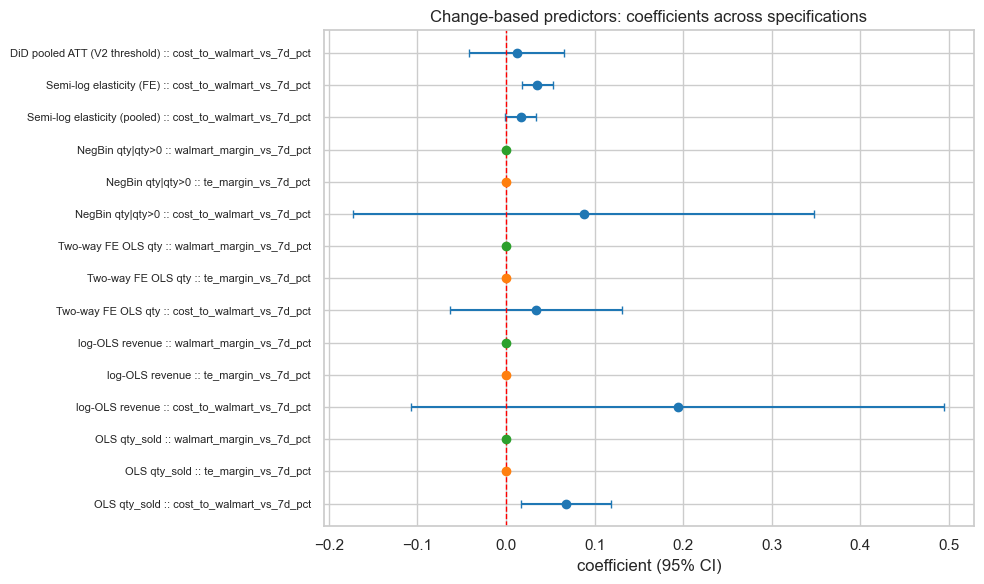


Saved: C:\Users\valen\Desktop\WalmartPricing\outputs\change_based_coefficients_2026-03-25.parquet


In [13]:
# Collect headline coefficients across specs
rows = []
for name, res in [("OLS qty_sold", ols_qty), ("log-OLS revenue", ols_rev)]:
    for _, r in res["coefficients"].iterrows():
        if r["variable"] in CHANGE_COLS:
            rows.append({"analysis": name, "predictor": r["variable"], "coef": r["coef"],
                         "ci_lower": r["ci_lower"], "ci_upper": r["ci_upper"],
                         "p_value": r["p_value"], "n_obs": res["n_obs"]})
for _, r in fe_res["coef_df"].iterrows():
    rows.append({"analysis": "Two-way FE OLS qty", "predictor": r["variable"], "coef": r["coef"],
                 "ci_lower": r["ci_lower"], "ci_upper": r["ci_upper"],
                 "p_value": r["p_value"], "n_obs": fe_res["n_obs"]})
if nb_res is not None:
    for _, r in nb_res["coef_df"].iterrows():
        if r["variable"] in CHANGE_COLS:
            rows.append({"analysis": "NegBin qty|qty>0", "predictor": r["variable"], "coef": r["coef"],
                         "ci_lower": r["ci_lower"], "ci_upper": r["ci_upper"],
                         "p_value": r["p_value"], "n_obs": nb_res["n_obs"]})
if elast_pooled:
    rows.append({"analysis": "Semi-log elasticity (pooled)", "predictor": "cost_to_walmart_vs_7d_pct",
                 "coef": elast_pooled["beta"], "ci_lower": elast_pooled["ci_lower"],
                 "ci_upper": elast_pooled["ci_upper"], "p_value": elast_pooled["p_value"],
                 "n_obs": elast_pooled["n_obs"]})
if elast_fe:
    rows.append({"analysis": "Semi-log elasticity (FE)", "predictor": "cost_to_walmart_vs_7d_pct",
                 "coef": elast_fe["beta"], "ci_lower": elast_fe["ci_lower"],
                 "ci_upper": elast_fe["ci_upper"], "p_value": elast_fe["p_value"],
                 "n_obs": elast_fe["n_obs"]})
if did_overall is not None:
    rows.append({"analysis": "DiD pooled ATT (V2 threshold)", "predictor": "cost_to_walmart_vs_7d_pct",
                 "coef": did_overall["ATT"], "ci_lower": did_overall["ci_lower"],
                 "ci_upper": did_overall["ci_upper"], "p_value": did_overall["p_value"],
                 "n_obs": did_overall["n_obs"]})

summary_df = pd.DataFrame(rows)
display(summary_df.round(5))

# Forest plot
fig, ax = plt.subplots(figsize=(10, max(4, 0.4 * len(summary_df))))
colors = {c: col for c, col in zip(CHANGE_COLS, ["#1f77b4", "#ff7f0e", "#2ca02c"])}
for i, r in summary_df.reset_index(drop=True).iterrows():
    c = colors.get(r["predictor"], "#666")
    ax.errorbar(r["coef"], i, xerr=[[r["coef"] - r["ci_lower"]], [r["ci_upper"] - r["coef"]]],
                fmt="o", color=c, capsize=3)
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_yticks(range(len(summary_df)))
ax.set_yticklabels([f"{r['analysis']} :: {r['predictor']}" for _, r in summary_df.iterrows()], fontsize=8)
ax.set_xlabel("coefficient (95% CI)")
ax.set_title("Change-based predictors: coefficients across specifications")
plt.tight_layout()
plt.show()

# Export
out_path = project_root / "outputs" / f"change_based_coefficients_{END_DATE}.parquet"
summary_df.to_parquet(out_path, index=False)
print(f"\nSaved: {out_path}")

In [14]:
if prep is not None:
    prep.close()
print("Done.")

2026-04-24 15:46:13,590 INFO Google API service connection closed.
2026-04-24 15:46:13,600 INFO Data warehouse adapter closed.


Done.
